# 02 — Feature Engineering

**Goal:** turn raw Lending Club fields into a model-ready matrix, persisted to `data/processed/` so downstream notebooks don't reload the 1.6 GB CSV.

Decisions baked in:
- **Numeric and categorical columns** chosen at-issuance only. No post-issuance leakage.
- **Engineered features:** `emp_length_years` (parsed from string), `installment_to_income`, `credit_history_years`.
- **Missingness preserved.** Imputation belongs in the model pipeline (different imputers fit LR vs GBM).
- **Maturity filter** applied so test-period economics aren't biased by early prepayers / early defaulters.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from credit_risk import data as cr_data, features as cr_feat

pd.set_option("display.max_columns", 100)

## Load and filter

In [2]:
df_raw = cr_data.load_raw()
df = cr_data.filter_to_completed_loans(df_raw)
df["realized_profit"] = df["total_pymnt"] - df["funded_amnt"]

snapshot = pd.to_datetime(df_raw["last_credit_pull_d"], format="%b-%Y", errors="coerce").max()
df_matured = cr_data.filter_to_matured_loans(df, snapshot_date=snapshot)

print(f"Raw rows:        {len(df_raw):,}")
print(f"Completed:       {len(df):,}")
print(f"Matured (final): {len(df_matured):,}")

Raw rows:        2,260,701
Completed:       1,345,310
Matured (final): 800,634


## Build features

In [3]:
X = cr_feat.build_features(df_matured)
y = cr_feat.target(df_matured)

print(f"Feature matrix shape: {X.shape}")
print(f"Default rate:         {y.mean():.4f}")
print(f"Numeric columns:      {sum(X.dtypes != object)}")
print(f"Object columns:       {sum(X.dtypes == object)}")

Feature matrix shape: (800634, 31)
Default rate:         0.1543
Numeric columns:      31
Object columns:       0


In [4]:
X.head()

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,total_acc,revol_bal,revol_util,collections_12_mths_ex_med,mort_acc,tot_cur_bal,total_rev_hi_lim,acc_now_delinq,term,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,application_type,initial_list_status,emp_length_years,installment_to_income,credit_history_years
0,3600.0,13.99,123.03,55000.0,5.91,675.0,679.0,0.0,1.0,7.0,0.0,13.0,2765.0,29.7,0.0,1.0,144904.0,9300.0,0.0,36 months,C,C4,MORTGAGE,Not Verified,debt_consolidation,PA,Individual,w,10.0,0.026843,12.334018
1,24700.0,11.99,820.28,65000.0,16.06,715.0,719.0,1.0,4.0,22.0,0.0,38.0,21470.0,19.2,0.0,4.0,204396.0,111800.0,0.0,36 months,C,C1,MORTGAGE,Not Verified,small_business,SD,Individual,w,10.0,0.151436,16.000000
5,11950.0,13.44,405.18,34000.0,10.20,690.0,694.0,0.0,0.0,5.0,0.0,6.0,8822.0,68.4,0.0,0.0,12798.0,12900.0,0.0,36 months,C,C3,RENT,Source Verified,debt_consolidation,GA,Individual,w,4.0,0.143005,28.167009
6,20000.0,9.17,637.58,180000.0,14.67,680.0,684.0,0.0,0.0,12.0,0.0,27.0,87329.0,84.5,0.0,4.0,360358.0,94200.0,0.0,36 months,B,B2,MORTGAGE,Not Verified,debt_consolidation,MN,Individual,f,10.0,0.042505,25.500342
7,20000.0,8.49,631.26,85000.0,17.61,705.0,709.0,1.0,0.0,8.0,0.0,15.0,826.0,5.7,0.0,3.0,141601.0,14500.0,0.0,36 months,B,B1,MORTGAGE,Not Verified,major_purchase,SC,Individual,w,10.0,0.089119,16.829569


## Missingness audit

We preserve NaNs in the saved parquet — the model pipeline handles imputation. But large-missingness columns are worth flagging now so we can decide whether to keep them, drop them, or add a missingness indicator.

In [5]:
missing = X.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(X) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df[missing_df["missing"] > 0]

,missing,pct
total_rev_hi_lim,67527,8.43
tot_cur_bal,67527,8.43
mort_acc,47281,5.91
emp_length_years,46362,5.79
revol_util,460,0.06
collections_12_mths_ex_med,56,0.01
dti,14,0.00
installment_to_income,12,0.00


## Categorical cardinality

In [6]:
cat_cols = [c for c in cr_feat.CATEGORICAL_FEATURES if c in X.columns]
cardinality = pd.Series({c: X[c].nunique(dropna=False) for c in cat_cols}).sort_values(ascending=False)
cardinality

addr_state             51
sub_grade              35
purpose                14
grade                   7
home_ownership          6
verification_status     3
term                    2
application_type        2
initial_list_status     2
dtype: int64

## Engineered feature distributions

Quick sanity check that the parsing worked.

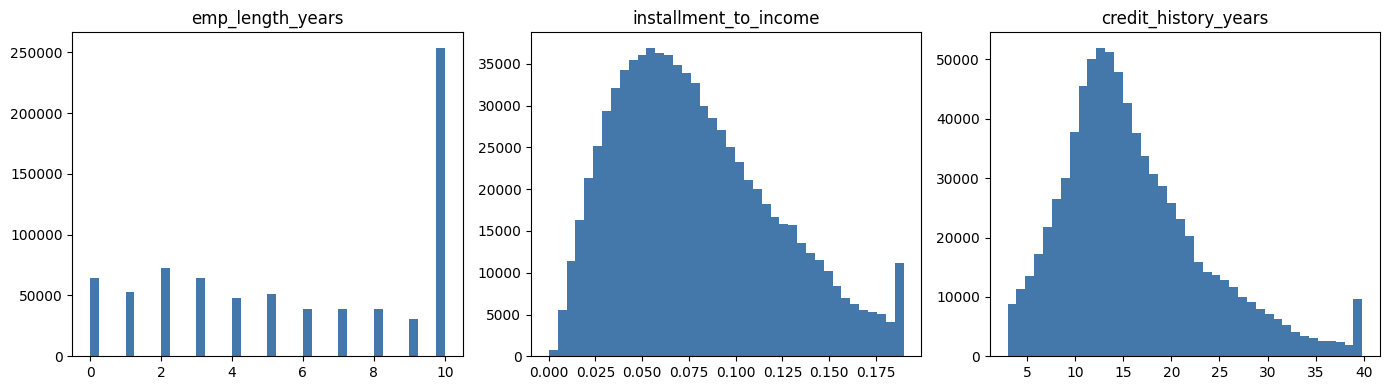

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["emp_length_years", "installment_to_income", "credit_history_years"]):
    series = X[col].dropna()
    cap = series.quantile(0.99)
    ax.hist(series.clip(upper=cap), bins=40, color="#4477aa")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Default rate by selected features

Sanity check that engineered features carry signal.

In [8]:
# Bin installment_to_income into deciles and check default rate per decile
audit = pd.DataFrame({
    "installment_to_income": X["installment_to_income"],
    "defaulted": y,
})
audit["i2i_decile"] = pd.qcut(audit["installment_to_income"], 10, duplicates="drop")
audit.groupby("i2i_decile", observed=True)["defaulted"].agg(["mean", "size"]).round(3)

,mean,size
i2i_decile,,
"(-0.000877, 0.0285]",0.111,80064
"(0.0285, 0.0405]",0.123,80061
"(0.0405, 0.0513]",0.125,80062
"(0.0513, 0.0616]",0.132,80062
"(0.0616, 0.0724]",0.140,80062
"(0.0724, 0.0841]",0.150,80062
"(0.0841, 0.098]",0.160,80074
"(0.098, 0.116]",0.177,80074
"(0.116, 0.14]",0.201,80038


## Persist train / test parquet

We bundle features + target + a few metadata columns (`realized_profit`, `issue_d`) into the parquet so downstream notebooks don't have to redo the data loading.

In [9]:
combined = X.copy()
combined["defaulted"] = y.values
combined["realized_profit"] = df_matured["realized_profit"].values
combined["issue_d"] = df_matured["issue_d"].values

train, test = cr_data.temporal_split(combined)
print(f"Train: {len(train):,} rows, {train.shape[1]} columns")
print(f"Test:  {len(test):,} rows, {test.shape[1]} columns")
print(f"\nTrain default rate: {train['defaulted'].mean():.4f}")
print(f"Test default rate:  {test['defaulted'].mean():.4f}")

Train: 691,399 rows, 34 columns
Test:  109,235 rows, 34 columns

Train default rate: 0.1514
Test default rate:  0.1728


In [10]:
cr_data.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
train_path = cr_data.PROCESSED_DIR / "train.parquet"
test_path = cr_data.PROCESSED_DIR / "test.parquet"

train.to_parquet(train_path, index=False)
test.to_parquet(test_path, index=False)

import os
print(f"Wrote {train_path}  ({os.path.getsize(train_path)/1e6:.1f} MB)")
print(f"Wrote {test_path}   ({os.path.getsize(test_path)/1e6:.1f} MB)")

Wrote /Users/rolandtuboly/projects/project_1/data/processed/train.parquet  (30.5 MB)
Wrote /Users/rolandtuboly/projects/project_1/data/processed/test.parquet   (5.2 MB)


## Takeaways

- **Feature matrix:** 31 features (19 numeric + 9 categorical + 3 engineered) on 800,634 matured loans. Default rate 15.4%.
- **Missingness — nothing alarming.** Top columns: `total_rev_hi_lim` and `tot_cur_bal` at 8.4% (newer schema fields not populated for older loans), `mort_acc` at 5.9%, `emp_length_years` at 5.8%. Everything else < 0.1%. The model pipeline imputes.
- **Cardinality.** `addr_state` (51), `sub_grade` (35), `purpose` (14) are the high-cardinality ones — these benefit from native categorical handling (LightGBM) or infrequent-category collapsing (LR).
- **Sanity check passed.** Default rate by `installment_to_income` decile climbs monotonically from **11.1% → 22.4%** — the strongest single-feature signal in the data.
- **Persisted.** `data/processed/train.parquet` (691k rows, 30 MB) and `test.parquet` (109k rows, 5 MB), each with features + target + `realized_profit` + `issue_d`.